In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import random
import afterglowpy as grb

from tqdm.notebook import tqdm
from scipy.integrate import quad, quad_vec, cumtrapz
from astropy.cosmology import Planck18 as cosmo
from orphans.tools import flux_to_mag

In [2]:
# constants and unit conversions
h = 6.62 * 1.0e-34      # Planck constant in J/Hz
c = 299792458.      # light speed in m/s
keV2J = 1e3 * 1.6e-19     # conversion keV to joules
erg2J = 1e-7        # conversion erg to joules

In [3]:
cosmo.luminosity_distance(0.0416)

<Quantity 190.11326265 Mpc>

## Method to create a population of GRBs

To create a population of sGRBs based on the SBAT4 catalog, we use the following method. The goal of the calculations is to compute the on-axis flux that would be received by the Swift BAT instrument considering the GRB parameters and to apply the cut that was applied on the sGRBs composing the SBAT4 catalog ($PF_{64} > 3.5$ ph/s/cm²). 

**1.** The first step is to generate useful parameters. The parameters used to compute the flux are the following: 
- $E_{Core}$: the energy of the jet core in erg,
- $\theta_{Core}$: the jet width in radians,
- $\theta_{Obs}$: the observer angle in radians, < $\theta_{Core}$ because we are on-axis here,
- $z$ and $d_L$: redshift and corresponding luminosity distance, assuming a Planck18 cosmology ($H_0$ = 67.66 km/(Mpc.s), $\Omega_0$ = 0.30966),
- $T_{90}$: duration of a GRB (< 2 seconds for short GRBs),
- $\Gamma_{Core}$: bulk Lorentz factor of the jet in the core.

All these parameters are generated according to a uniform distribution, except the redshift which follows the following distribution:
$$ P(z) = \frac{\frac{dV_c}{dz} \frac{\dot \rho_{sGRBs}}{1+z}}{\int_0^\infty\frac{dV_c}{dz} \frac{\dot \rho_{sGRBs}}{1+z}dz} $$

**2.** The isotropic equivalent energy of the jet emitted at the observer angle is then computed thanks to a power-law angular energy structure:
$$ E(\theta_{Obs}) = E_{Core}\left(1 + \frac{1}{b}\left(\frac{\theta_{Obs}}{\theta_{Core}}\right)\right)^{b/2} $$
Where $b$ = 4 to have a quite "steep" structure. $E_{\gamma, iso}$ is then computed by taking a small portion of the total $E_{iso}$: $E_{\gamma, iso} = \eta_\gamma E_{iso} \approx 0.1 E_{iso}$ ($\eta_\gamma$ is called the prompt efficiency, but this is something to check more thoroughly).

The Lorentz factor at the observer angle is computed thanks to:
$$ \Gamma(\theta_{Obs}) = 1 + \frac{\Gamma_{Core} - 1}{1 + \left(\frac{\theta_{Obs}}{\theta_{Core}}\right)^a} $$
Where $a$ = 3.5. 

All of these variables are stored in a list of dictionaries.

**3.** We want to compute the flux that would be received by Swift BAT, in $photons/s/cm^2$:
$$ \frac{d \dot N}{dA} = \int_{15keV}^{150keV} \frac{F_\nu}{h\nu} d\nu $$

With $F_\nu = \frac{1+z}{4\pi d_L²} L_\nu = \frac{1+z}{4\pi d_L²} \left(\frac{hL}{E_p}\right) S(\nu')$, where:
- $E_p = \Gamma E_p'$ is the peak energy in the observer frame, $E_p'$ is the peak energy in the comoving frame and is set to 3 keV,
- $L = 2 \times \frac{E_{iso}}{T_{90}}$ is the average luminosity (factor 2 being here to correct the fact that we take into account the average luminosity and not the peak luminosity),
- $S(\nu') \propto \nu'^a \exp \left[(−(1 + a)\frac{\nu'}{\nu_p'}\right]$ is a cut-off power-law spectral shape, to cut the luminosity at high energies, with a spectral index a=0.3 (normalized).

**4.** The obtained flux $\frac{d \dot N}{dA}$ is called $F_{BAT}$ and is compared to the SBAT4 $PF_{64}$, which is the peak photon flux computed using the 15–150 keV Swift-BAT light curves binned with $\delta t$ = 64 ms. To select only the GRBs that look like the SBAT4 catalog, we apply on our simulated GRBs fluxes the same cut that was applied to the SBAT4 GRBs ($F_{BAT} > 3.5$ photons/s/cm²).

## Defining some useful functions...

In [4]:
def generate_grb_population(nb_grbs):
    """ Function to generate a population of GRBs
    """
    
    grb_population = []

    # generate randomly some parameters
    ECore = np.random.uniform(47, 54, nb_grbs)    # in erg
    thetaCore = np.random.uniform(0.01, 0.3, nb_grbs)   # in radians
    #thetaWing = random.uniform(thetaCore+0.01, np.pi/2)   # in radians
    thetaObs = np.arccos(np.random.uniform(0., 1., nb_grbs))   # in radians
    n = 10 ** (-np.random.uniform(-2, 2, nb_grbs))   # in cm-3
    z = np.random.choice(z_list, nb_grbs)
    dL = cosmo.luminosity_distance(z).value * 3.08e22   # in m
    T90 = np.random.uniform(0.01, 2., nb_grbs)  # T90 in seconds
    
    # calculate the Lorentz factor
    GammaCore = 10 ** np.random.uniform(2., 3., nb_grbs)
    Gamma = lorentz_factor(GammaCore, thetaObs, thetaCore)
    
    E = 10**ECore * (1 + (1/4) * (thetaObs/thetaCore)**2)**(-4/2) # power-law angular structure of the energy
    eta_gamma = 0.1
    Eiso = E * eta_gamma   # conversion of the energy to gamma radiation energy
    
    # tore the parameters of the simulated GRB
    grb = {'Eiso': Eiso,
           'E0': 10**ECore,
           'thetaCore': thetaCore,
           'thetaObs': thetaObs,
           'n': n,
           'z': z,
           'dL': dL,
           'Gamma': Gamma,
           'T90': T90
           }
    
    Fbat = calculate_bat_flux(grb)
    grb['Fbat'] = Fbat

    return grb


def calculate_flux(nu, grb):
    """Function to calculate the spectral luminosity of the GRB at the viewing angle
    """
    
    Eiso = grb['Eiso'] * erg2J    # energy in Joule
    thetaCore = grb['thetaCore']
    thetaObs = grb['thetaObs']
    z = grb['z']
    dL = grb['dL']
    Gamma = grb['Gamma']
    T90 = grb['T90']
    
    Ep_comoving = 3. * keV2J    # energy of the peak in the rest-frame in J
    nup_prime = Ep_comoving / h    # convert the energy of the peak in a frequency
    a = 0.3   # spectral index (typical)

    Ep = Gamma * Ep_comoving
    L = 2 * Eiso / T90   # in J/s
    nu_prime = nu / (1+z)
    
    # cut-off power law comoving spectral shape
    # numerical integration to normalize the flux
    nu_values = np.linspace(15*keV2J/h, 150*keV2J/h, 1000)    # BAT frequency range
    norm = np.trapz(spectral_shape(nu_values, nup_prime, a))
    # normalized spectral shape
    normalized_S = spectral_shape(nu_prime, nup_prime, a) / norm
    
    Lnu = (h * L / Ep) * normalized_S

    Fnu = (1+z) / (4*np.pi*dL**2) * Lnu
    
    # convert the flux in a flux of photons
    Fphot = Fnu / (h*nu)

    return Fphot


def spectral_shape(nu_prime, nup_prime, a):
    """Function to calculate the cut-off power law comoving spectral shape (has to be normalized): 
    S(ν') ∝ ν'^3.5 * exp(−(1 + 3.5)ν'/νp')
    (arXiv:1905.01190v2)
    """
    
    S = nu_prime**a * np.exp(-(1+a) * (nu_prime/nup_prime))
    
    return S


def lorentz_factor(GammaCore, thetaObs, thetaCore):
    """Function to calculate the Lorentz factor: 
    Γ(θ) = 1 + (Γc − 1) / (1 + (θ/θc))^3.5
    (arXiv:1905.01190v2)
    """
    
    Gamma = 1 + (GammaCore - 1) / (1 + (thetaObs/thetaCore)**3.5)

    return Gamma
    
    
def calculate_bat_flux(grb):
    """Calculate the flux of the GRB received by Swift BAT
    """
        
    nu_min = 15. * keV2J / h   # min frequency of BAT in Hz
    nu_max = 150. * keV2J / h   # max frequency of BAT in Hz
    Fbat, err = quad_vec(calculate_flux, nu_min, nu_max, args=grb)

    return Fbat * 1e-4   # in photons/s/cm2

In [5]:
# SBAT4 catalog data
# list of GRBs from D'Avanzo et al. 2014
catalog = {'grb_name': ['051221A', '070714B', '080123', '080905A', '090426', '090510', '090515', '100117A', 
                        '100625A', '101219A', '111117A', '130603B'],
           'z': [0.547, 0.92, 0.495, 0.122, 2.609, 0.903, 0.403, 0.92, 0.452, 0.718, 1.3, 0.356],
           'T90': [1.4, 80.0, 115.18, 1.02, 1.24, 0.3, 0.04, 0.3, 0.33, 0.6, 0.47, 0.18],   # in seconds
           'flux': [40.7, 8.1, 6.1, 3.7, 4.7, 20.1, 5.2, 4.4, 9.3, 8.9, 5.8, 54.2]}  # in photons/cm2/s


# generating a redshift distribution
z0 = np.linspace(0., 2.6, 1000)
pdf = cosmo.differential_comoving_volume(z0) / (1+z0)
pdf /= np.trapz(pdf, z0)
cdf = cumtrapz(pdf, z0, initial=0)
z_list = np.interp(np.random.uniform(0., 1., 1000), cdf, z0)
print(z_list[z_list<0.1])  # ~ detection limit of LIGO-Virgo for BNS


# generate population of GRBs 
nb_grbs = 10000  # number of simulated GRBs

print(f'Generating {nb_grbs} GRBs...')
grb_population = generate_grb_population(nb_grbs)

print('Keeping GRBs with a flux > 3.5 ph/s/cm2...')
cut = 3.5    # cut applied to the SBAT4 catalog (PF64 > 3.5 ph/s/cm2)
cut_grbs = dict()
for k in grb_population.keys():
    cut_grbs[k] = grb_population[k][np.where(grb_population['Fbat'] > cut)]

print('Done!')
print(f"Number of GRBs left: {len(cut_grbs['E0'])}")

[0.06369525]
Generating 10000 GRBs...
Keeping GRBs with a flux > 3.5 ph/s/cm2...
Done!
Number of GRBs left: 1130


Text(0, 0.5, 'Number of GRBs')

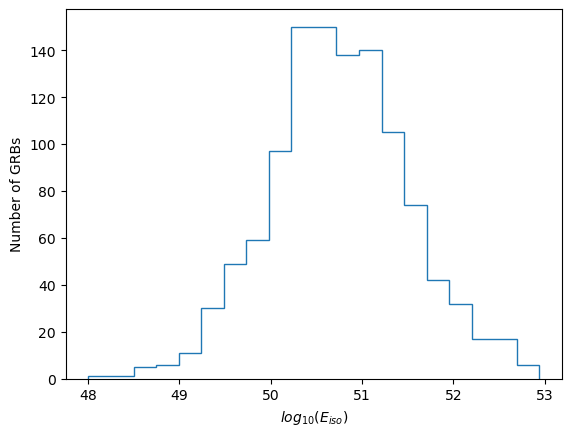

In [6]:
E0 = cut_grbs['Eiso']

plt.hist(np.log10(E0), bins=20, histtype='step');
plt.xlabel('$log_{10}(E_{iso})$')
plt.ylabel('Number of GRBs')

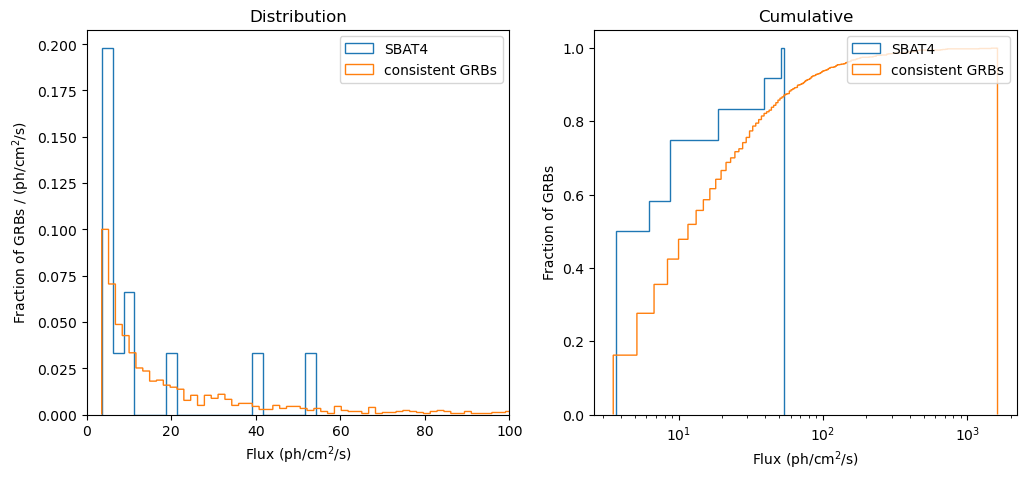

In [7]:
Fbat = cut_grbs['Fbat']
fig, ax = plt.subplots(figsize=(12,5), nrows=1, ncols=2)

ax[0].hist(catalog['flux'], bins=20, density=True, histtype='step', label='SBAT4')
ax[0].hist(Fbat, bins=1000, density=True, histtype='step', label='consistent GRBs');
ax[0].set_xlabel('Flux (ph/cm$^2$/s)')
ax[0].set_ylabel('Fraction of GRBs / (ph/cm$^2$/s)')
ax[0].set_title('Distribution')
ax[0].set_xlim(-0.01, 100)
ax[0].legend()

ax[1].hist(catalog['flux'], bins=20, histtype='step', density=True, cumulative=True, label='SBAT4')
ax[1].hist(Fbat, bins=1000, histtype='step',  density=True, cumulative=True, label='consistent GRBs');
ax[1].set_xlabel('Flux (ph/cm$^2$/s)')
ax[1].set_ylabel('Fraction of GRBs')
#ax[1].set_xlim(-0.01, 200)
ax[1].set_xscale('log')
ax[1].set_title('Cumulative');
ax[1].legend()

## Generating GRBs consistent with the SBAT4 catalog

In [8]:
nb_grbs = 1000
nb_cut_grbs = 1000

cut = 3.5 

grb_pop = {'Eiso': np.array([]),
           'E0': np.array([]),
           'thetaCore': np.array([]),
           'thetaObs': np.array([]),
           'n': np.array([]),
           'z': np.array([]),
           'dL': np.array([]),
           'Gamma': np.array([]),
           'T90': np.array([]),
           'Fbat': np.array([])
           }

cut_grbs.update(grb_pop)

print(f"Generating at least {nb_cut_grbs} GRBs with a flux > {cut} ph/s/cm² and z<0.1...")

# Simulating a certain amount of GRBs with z<0.1
while len(cut_grbs['z'][cut_grbs['z']<0.1]) < nb_cut_grbs:

    # generating a redshift distribution
    z0 = np.linspace(0., 2.6, 1000)
    pdf = cosmo.differential_comoving_volume(z0) / (1+z0)
    pdf /= np.trapz(pdf, z0)
    cdf = cumtrapz(pdf, z0, initial=0)
    z_list = np.interp(np.random.uniform(0., 1., 1000), cdf, z0)
    
    grbs = generate_grb_population(nb_grbs)

    for k in grbs.keys():
        
        key = np.append(grb_pop[k], grbs[k])
        grb_pop[k] = key
        
        cut_key = np.append(cut_grbs[k], grbs[k][np.where(grbs['Fbat'] > cut)])
        cut_grbs[k] = cut_key
        
print('Done!')
print(f"Generated {len(cut_grbs['E0'])} GRBs with a flux > {cut} ph/s/cm².")

Generating at least 1000 GRBs with a flux > 3.5 ph/s/cm²...
Done!
Generated 632772 GRBs with a flux > 3.5 ph/s/cm².


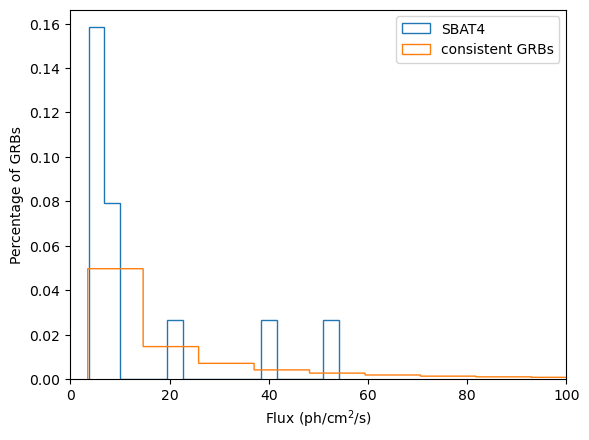

In [10]:
cut_Fbat = cut_grbs['Fbat']

plt.hist(catalog['flux'], bins=16, histtype='step', density=True, label='SBAT4')
plt.hist(cut_Fbat, bins=2000, histtype='step', density=True, label='consistent GRBs')
plt.xlabel('Flux (ph/cm$^2$/s)')
plt.ylabel('Percentage of GRBs')
plt.xlim(-0.01, 100)
plt.legend()

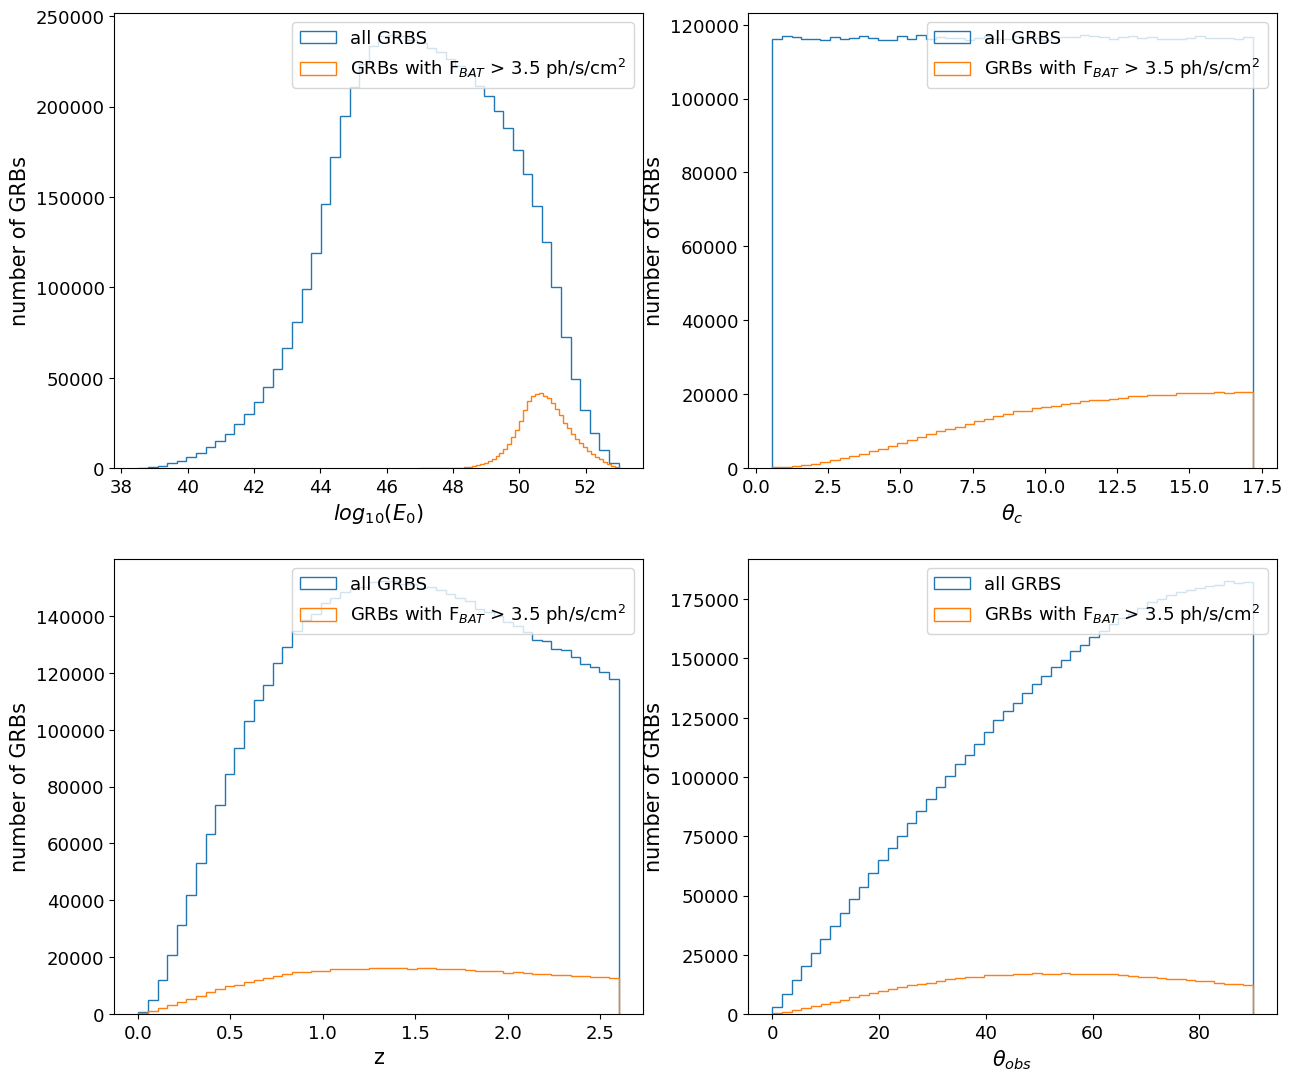

In [11]:
# all generated parameters distributions
E0_all = grb_pop['Eiso']
thetaCore_all = grb_pop['thetaCore']
Gamma_all = grb_pop['Gamma']
z_all = grb_pop['z']
thetaObs_all = grb_pop['thetaObs']

# parameters distributions for consistent GRBs
E0_cut = cut_grbs['Eiso']
thetaCore_cut = cut_grbs['thetaCore']
Gamma_cut = cut_grbs['Gamma']
z_cut = cut_grbs['z']
thetaObs_cut = cut_grbs['thetaObs']


params_all = [np.log10(E0_all), np.degrees(thetaCore_all), z_all, np.degrees(thetaObs_all)]
params_cut = [np.log10(E0_cut), np.degrees(thetaCore_cut), z_cut, np.degrees(thetaObs_cut)]
labels = ['$log_{10}(E_{0})$', r'$\theta_c$', 'z', r'$\theta_{obs}$']

plt.rcParams.update({'font.size': 13})
fig, axes = plt.subplots(figsize=(15,13), nrows=3, ncols=2)

for i in range(4):
    
    ax = plt.subplot(2,2,i+1)
    ax.hist(params_all[i], bins=50, histtype='step', label='all GRBS');
    ax.hist(params_cut[i], bins=50, histtype='step', label='GRBs with F$_{BAT}$ > 3.5 ph/s/cm$^2$');

    ax.set_ylabel('number of GRBs', fontsize=15)
    ax.set_xlabel(labels[i], fontsize=15)
    ax.legend()

In [12]:
cut_grbs['z']

array([0.46768233, 1.02171785, 2.00479233, ..., 0.90278208, 1.30868966,
       0.67452252])

In [13]:
min(cut_grbs['z'])

0.003510011672780886

In [14]:
# Indexes of the configuration that have z<0.1
z_01 = np.where(cut_grbs['z']<0.1)[0]

In [15]:
z_01

array([  1034,   1346,   1466,   1782,   2344,   2473,   2833,   3829,
         3885,   3963,   4555,   6043,   6869,   7432,   7835,   7919,
         8199,   8238,   8315,   9930,   9949,  10528,  10760,  10833,
        10852,  11187,  11461,  11543,  11883,  12294,  13204,  14130,
        14525,  15455,  15722,  15766,  15885,  16060,  16351,  16501,
        18926,  19916,  20950,  22100,  23813,  24153,  26308,  26319,
        26666,  27789,  28119,  29502,  29922,  30382,  30456,  31029,
        32067,  32198,  33585,  33738,  34583,  34966,  35056,  35059,
        35355,  35600,  35875,  36413,  37053,  41176,  41386,  43740,
        44532,  46181,  46883,  49517,  49860,  50516,  50546,  51434,
        51747,  51981,  52028,  52157,  52188,  52293,  52489,  52495,
        52707,  53196,  53788,  54309,  54753,  55223,  55339,  55797,
        55850,  56561,  56779,  58683,  58934,  59429,  60196,  61028,
        63551,  63594,  64816,  65554,  65760,  66521,  66605,  67209,
      

## Method to keep only the "orphans" GRBs

Now that we have a population of GRBs that is consistent with the SBAT4 catalogue, we want to keep only the GRBs that would have an orphan afterglow (ie an afterglow without a prompt emission). To do that, we compute the flux of the afterglow and keep only those that have a maximum flux below the detection limit of Fermi GBM in the 50-300 keV band.

For each configuration of ($E_0$, $\theta_{obs}$, $\theta_c$, $n_0$, $z$), we compute the afterglow spectral flux with `afterglowpy` in J/m²/s/Hz (knowing that 1 mJy = 10⁻²⁹ J/m²/s/Hz). We then keep only the maximum value. To compute the flux in ph/cm²/s, we use: $F_{photon} = F_\nu / (h\nu) \times 10^{-4}$, $h$ being the Planck constant.

To have the flux over the whole band, we integrate $F_{photon}$ between the 50 and 300 keV: $F = 10^{-4} \times \int_{50keV}^{300keV} \frac{F_\nu}{h\nu} d_\nu$.

In [16]:
nu_min_gbm = 50. * keV2J / h
nu_max_gbm = 300. * keV2J / h

t = np.geomspace(1.0e-3, 1.0e4, 100)  # time in days
#nu = np.linspace(nu_min_gbm, nu_max_gbm, 100)

def flux(n, params):
        
    grb_params = {'jetType':     grb.jet.PowerLaw,     # Top-Hat jet
                  'specType':    0,      # Basic Synchrotron Emission Spectrum
                  'b':           4,      # Power-Law index
                  'thetaObs':    params[0],    # Viewing angle in radians
                  'E0':          params[1], # Isotropic-equivalent energy in erg
                  'thetaCore':   params[2],    # Half-opening angle in radians
                  'thetaWing':   np.pi/2,   # Truncature angle
                  'n0':          params[3],    # circumburst density in cm^{-3}
                  'p':           2.2,    # electron energy distribution index
                  'epsilon_e':   0.1,    # epsilon_e
                  'epsilon_B':   0.01,   # epsilon_B
                  'xi_N':        1.0,    # Fraction of electrons accelerated
                  'd_L':         cosmo.luminosity_distance(params[4]).value * 3.08e24, # Luminosity distance in cm
                  'z':           params[4]}   # Redshift

    Fnu = grb.fluxDensity(t*grb.day2sec, n, **grb_params) * 1e-29   # flux in J/m2/s/Hz
    
    return Fnu



def flux_max(n, E0, thetaCore, thetaObs, n0, z):
    
    params = [thetaObs, E0, thetaCore, n0, z]
    Fnu = max(flux(n, params))
        
    Fphot = np.array(Fnu) / (h*n)  # photon flux
    return Fphot   



def integrate_flux(E0, thetaCore, thetaObs, n0, z):
    
    Fgbm, err = quad(flux_max, nu_min_gbm, nu_max_gbm, args=(E0, thetaCore, thetaObs, n0, z))

    return Fgbm * 1e-4
    
"""
Fgbm = []
for i in tqdm(range(100)):
    
    E0 = cut_grbs['E0'][i]
    thetaCore = cut_grbs['thetaCore'][i]
    thetaObs = cut_grbs['thetaObs'][i]
    n0 = cut_grbs['n'][i]
    z = cut_grbs['z'][i]
    
    with concurrent.futures.ThreadPoolExecutor(max_workers=4) as executor:
        futures = [fgbm, err = quad(flux_max, nu_min_gbm, nu_max_gbm, args=(E0, thetaCore, thetaObs, n0, z), limit=100) 
                   for i in range(100)]
        for future in concurrent.futures.as_completed(futures):
            spots_df_list.append(future.result())
            
    

    Fgbm.append(fgbm * 1.0e-4)   # in ph/cm2/s



for i in tqdm(range(len(cut_grbs['E0']))
    
    E0 = cut_grbs['E0']
    thetaCore = cut_grbs['thetaCore']
    thetaObs = cut_grbs['thetaObs']
    n = cut_grbs['n']
    z = cut_grbs['z']

    params = [thetaObs, E0, thetaCore, n, z]

    fgbm, err = quad_vec(flux_max, nu_min_gbm, nu_max_gbm, args=cut_grbs)

    Fgbm.append(fgbm * 1.0e-4) """

"\nFgbm = []\nfor i in tqdm(range(100)):\n    \n    E0 = cut_grbs['E0'][i]\n    thetaCore = cut_grbs['thetaCore'][i]\n    thetaObs = cut_grbs['thetaObs'][i]\n    n0 = cut_grbs['n'][i]\n    z = cut_grbs['z'][i]\n    \n    with concurrent.futures.ThreadPoolExecutor(max_workers=4) as executor:\n        futures = [fgbm, err = quad(flux_max, nu_min_gbm, nu_max_gbm, args=(E0, thetaCore, thetaObs, n0, z), limit=100) \n                   for i in range(100)]\n        for future in concurrent.futures.as_completed(futures):\n            spots_df_list.append(future.result())\n            \n    \n\n    Fgbm.append(fgbm * 1.0e-4)   # in ph/cm2/s\n\n\n\nfor i in tqdm(range(len(cut_grbs['E0']))\n    \n    E0 = cut_grbs['E0']\n    thetaCore = cut_grbs['thetaCore']\n    thetaObs = cut_grbs['thetaObs']\n    n = cut_grbs['n']\n    z = cut_grbs['z']\n\n    params = [thetaObs, E0, thetaCore, n, z]\n\n    fgbm, err = quad_vec(flux_max, nu_min_gbm, nu_max_gbm, args=cut_grbs)\n\n    Fgbm.append(fgbm * 1.0e-4)

In [ ]:
nu_r = 482703137570394.2

#for i in z_01:
all_z = []
for i in tqdm(range(100000)):
    
    E0 = cut_grbs['Eiso'][i]
    thetaCore = cut_grbs['thetaCore'][i]
    thetaObs = cut_grbs['thetaObs'][i]
    n0 = cut_grbs['n'][i]
    z = cut_grbs['z'][i]
    
    grb_params = {'jetType':     grb.jet.PowerLaw,     # Top-Hat jet
                  'specType':    0,      # Basic Synchrotron Emission Spectrum
                  'b':           4,      # Power-Law index
                  'thetaObs':    thetaObs,    # Viewing angle in radians
                  'E0':          E0, # Isotropic-equivalent energy in erg
                  'thetaCore':   thetaCore,    # Half-opening angle in radians
                  'thetaWing':   np.pi/2,   # Truncature angle
                  'n0':          n0,    # circumburst density in cm^{-3}
                  'p':           2.2,    # electron energy distribution index
                  'epsilon_e':   0.1,    # epsilon_e
                  'epsilon_B':   0.01,   # epsilon_B
                  'xi_N':        1.0,    # Fraction of electrons accelerated
                  'd_L':         cosmo.luminosity_distance(z).value * 3.08e24, # Luminosity distance in cm
                  'z':           z}   # Redshift
    
    Fnu = grb.fluxDensity(t*grb.day2sec, nu_r, **grb_params)
    mag_peak = flux_to_mag(max(Fnu))
    
    if mag_peak < 24.5 and thetaCore < thetaObs:
        all_z.append(z)
        #print(E0, thetaCore, thetaObs, n0, z)
        #print(i, mag_peak)

  0%|          | 0/100000 [00:00<?, ?it/s]

In [29]:
np.array(all_z)[np.array(all_z)<0.1]

array([], dtype=float64)

In [161]:
# The integration of the flux is time consuming so the process is run over all the CPUs

import concurrent.futures

Fgbm_z_01 = []

E0 = cut_grbs['Eiso']
thetaCore = cut_grbs['thetaCore']
thetaObs = cut_grbs['thetaObs']
n0 = cut_grbs['n']
z = cut_grbs['z']
    
with concurrent.futures.ThreadPoolExecutor(max_workers=4) as executor:
    futures = [executor.submit(integrate_flux, E0[i], thetaCore[i], thetaObs[i], n0[i], z[i]) 
               for i in [z_01[k] for k in range(100)]]
    print('Done!')
    i = 0
    for future in concurrent.futures.as_completed(futures):
        Fgbm_z_01.append(future.result())
        print(i)
        i += 1
        #Fgbm_test.append(future)   # in ph/cm2/s


Done!
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18


/tmp/ipykernel_227560/929226673.py:42: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  Fgbm, err = quad(flux_max, nu_min_gbm, nu_max_gbm, args=(E0, thetaCore, thetaObs, n0, z), limit=100)


19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43


/tmp/ipykernel_227560/2574630604.py:42: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  Fgbm, err = quad(flux_max, nu_min_gbm, nu_max_gbm, args=(E0, thetaCore, thetaObs, n0, z))


44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [165]:
Fgbm_z_01

IOStream.flush timed out


[3.1595518567907466e-08,
 0.000426327351702323,
 0.0001451959275604352,
 1.8275976971991927e-05,
 3.661192764961002e-08,
 2.707332190683724e-05,
 0.0001802861563617366,
 7.253402856004058e-05,
 0.004037508086374409,
 3.868389466898962e-06,
 1.4647454108230705e-05,
 6.086770600429792e-08,
 3.7960643243437874e-05,
 0.0027299437568508718,
 1.8491755595867582e-07,
 0.0007075364239690308,
 4.1645387995517624e-05,
 7.227946835321111e-07,
 0.028749071113633878,
 5.7974598061902286e-05,
 1.981634789332758e-05,
 8.536721907304307e-08,
 5.773780209558664e-07,
 1.1153283459329826e-06,
 3.5254827377044418e-09,
 4.131811762908671e-05,
 4.1608558589129574e-05,
 0.0010200290707217978,
 3.398813464897125e-06,
 2.106842770300853e-05,
 0.006913845561826401,
 0.00017520152967355373,
 3.0218281206340338e-06,
 5.59521395281159e-06,
 8.079313293396491e-08,
 1.441640218193013e-08,
 1.1084794002769578e-06,
 7.054488147213363e-05,
 0.000611544496122901,
 0.006133317470612998,
 7.1865364800923206e-06,
 0.005162

In [19]:
Fgbm_z_01 = [3.1595518567907466e-08, 0.000426327351702323, 0.0001451959275604352, 1.8275976971991927e-05, 
             3.661192764961002e-08, 2.707332190683724e-05, 0.0001802861563617366, 7.253402856004058e-05,
             0.004037508086374409, 3.868389466898962e-06, 1.4647454108230705e-05, 6.086770600429792e-08,
             3.7960643243437874e-05, 0.0027299437568508718, 1.8491755595867582e-07, 0.0007075364239690308, 
             4.1645387995517624e-05, 7.227946835321111e-07, 0.028749071113633878, 5.7974598061902286e-05,
             1.981634789332758e-05, 8.536721907304307e-08, 5.773780209558664e-07, 1.1153283459329826e-06,
             3.5254827377044418e-09, 4.131811762908671e-05, 4.1608558589129574e-05, 0.0010200290707217978,
             3.398813464897125e-06, 2.106842770300853e-05, 0.006913845561826401, 0.00017520152967355373,
             3.0218281206340338e-06, 5.59521395281159e-06, 8.079313293396491e-08, 1.441640218193013e-08,
             1.1084794002769578e-06, 7.054488147213363e-05, 0.000611544496122901, 0.006133317470612998,
             7.1865364800923206e-06, 0.00516270226030963, 7.004689139699386e-05, 0.0003631662013107377,
             4.904705506985996e-05, 3.6179990603039954e-06, 1.2838776417207996e-06, 1.5559077238488416e-09,
             1.9334215819743334e-05, 1.8858679233378366e-06, 1.5087545057392405e-09, 0.0004461424791583363,
             7.678028125495806e-05, 4.711624956479982e-10, 1.7261090448169833e-06, 3.0318855698312224e-10,
             0.0028365197976242783, 1.0241245619938545e-05, 0.0005541736429942847, 5.881444413495686e-07,
             1.899453365056863e-07, 0.0001394962447770501, 0.0014358674363459667, 0.0001222998520764761,
             3.838126234687031e-06, 1.5901906819155017e-08, 9.247173416898574e-05, 1.0484659478420567e-06,
             1.0518982828500543e-05, 1.152912254140974e-06, 2.1239356511547014e-09, 3.730609023117017e-08,
             3.7987061423082604e-05, 0.0004721441853641359, 0.0001467626496992815, 8.158748134789562e-08,
             0.0014640418488071774, 1.36111231361911e-06, 1.9574626356720046e-06, 2.5473819953531555e-07,
             1.5838671490582515e-06, 3.1688428799100016e-06, 6.894605585462496e-06, 8.110825541975561e-05,
             3.093308572674863e-05, 0.00048671889511393336, 3.8960381830925933e-07, 5.59957480216802e-05,
             5.6204663550322435e-05, 9.68201431866128e-08, 0.0037146517608320907, 0.006617140609444016,
             0.11579611509725742, 3.1682955894432234e-09, 0.005453998428055157, 0.0006588294262616612,
             1.2227970418527028e-08, 1.1313126209166647e-06, 0.0002514459932021767, 1.999437745125727e-05]

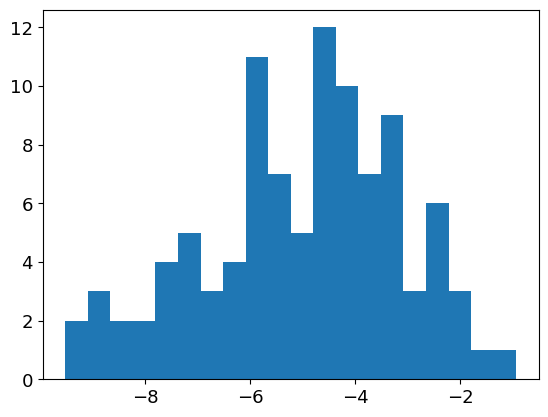

In [22]:
plt.hist(np.log10(np.array(Fgbm_z_01)), bins=20);

In [29]:
for i in range(len(cut_grbs['E0'])):
    if cut_grbs['thetaObs'][i] < cut_grbs['thetaCore'][i]:
        print(i)

9
131
162
303
383
412
416
429
545
580
625
644
680
725
810
881
1036
1074
1212
1279
1370
1457
1534
1775
1909
2039
2078
2232
2347
2375
2400
2443
2558
2656
2700
2775
2831
2869
2877
3054
3200
3257
3262
3446
3588
3645
3681
3686
3756
3792
3843
3850
3888
3903
3931
3951
3959
4051
4336
4338
4343
4346
4350
4428
4447
4489
4596
4651
4671
4774
4830
4875
4989
5017
5047
5356
5395
5413
5546
5567
5570
5626
5805
5872
5879
6055
6244
6262
6325
6413
6470
6484
6503
6538
6633
6657
6686
6705
6709
6722
6756
6807
6839
6880
6897
6935
7051
7083
7159
7202
7259
7295
7311
7354
7379
7386
7482
7563
7573
7577
7596
7608
7632
7669
7723
7724
7740
7891
7929
7966
8063
8096
8099
8119
8151
8168
8348
8358
8514
8592
8602
8743
8774
9000
9005
9025
9162
9303
9340
9450
9455
9634
9657
9683
9769
9792
9894
9961


In [25]:
Fgbm_100

[5.052252644546273e-07,
 5.021978552467854e-09,
 3.392853616777285e-10,
 1.147733048100593e-09,
 5.534650928163561e-11,
 2.277809340560398e-09,
 6.756140777367943e-10,
 1.3496976984818223e-10,
 9.736273099133002e-09,
 6.6383070664784915e-09,
 3.3793612997349356e-09,
 3.399351546181334e-10,
 1.4312720446983012e-11,
 1.076174487437991e-09,
 9.158099583640127e-11,
 1.8914429691546815e-06,
 4.534190462286534e-08,
 2.4667372539960753e-09,
 1.6698559055859994e-10,
 2.601022230781286e-09,
 1.158608267761414e-09,
 2.1131719979244355e-11,
 3.949913646441313e-09,
 6.520142702697148e-10,
 1.6708988787430807e-09,
 3.7036132999262312e-09,
 1.1779745272196957e-10,
 8.42279764642492e-10,
 1.2451238412860902e-09,
 1.5483843917226865e-10,
 1.3997729521247415e-09,
 4.2149504103889586e-10,
 2.0115319748285198e-10,
 2.5511337493007967e-08,
 3.794269209873823e-07,
 2.7166105644043966e-09,
 8.874923318403547e-11,
 5.34270763086892e-10,
 3.126282009214776e-09,
 3.741928875815457e-11,
 5.867621751003261e-12,


In [19]:
Fgbm_test

[2.5499620178887e-07,
 3.6159010363521865e-07,
 3.9693782569349203e-07,
 6.263635461017192e-08,
 7.38409511419602e-07,
 1.4964608210752901e-05,
 4.815295561946361e-06,
 5.752686911460387e-07,
 1.7994467823499374e-06,
 3.1159398358809946e-05,
 2.8238104297287e-07,
 2.824262158867325e-08,
 8.994547585166936e-09,
 1.1073746122286176e-06,
 3.426847672513691e-07,
 2.9345009492176815e-06,
 6.776808506323909e-08,
 3.3995320333604988e-06,
 1.0738407931002492e-06,
 1.049258109493274e-06,
 1.0272739466471605e-06,
 9.711021579614202e-08,
 8.620603906042962e-07,
 1.0751573273040158e-06,
 5.541680082011814e-07,
 2.440860843765907e-06,
 4.1819319676681566e-07,
 3.103438832753612e-07,
 5.968106841203187e-08,
 3.190225374259053e-07,
 2.5270789524286884e-07,
 7.970827520793214e-07,
 8.568535395959393e-07,
 7.852658154011451e-06,
 1.4542725563183865e-06,
 9.569523622981742e-06,
 4.907342848023152e-07,
 6.847807648172362e-07,
 8.970737954293647e-08,
 2.0485292409192836e-07,
 4.6583156500199006e-08,
 2.64

In [21]:
len(Fgbm_test)

10048

In [23]:
len(np.array(Fgbm_test)[np.array(Fgbm_test) < 0.5])

10048

In [ ]:
plt.hist(Fgbm, bins=100);